# Chapter 5: Examples of Surfaces

**Source span:** Pressley, Chapter 5, printed pp. 95-120; PDF pp. 102-126; sections 5.1-5.6.

**Chapter question:** How do the main surface recipes in three-dimensional geometry become regular surfaces, and what computational tests reveal when a recipe changes chart type, loses regularity, or carries topology?

This notebook is a standalone, visualization-first tour. The source pages were used for orientation only; the prose, code, diagrams, and checks below are original.

## Computational Translation Guide

| Pressley idea | Computational object | Inspection target | Check |
| --- | --- | --- | --- |
| Level surface | Scalar field `F(x, y, z)` and its gradient | Does `grad F` vanish on the visible zero set? | symbolic gradient identities and sampled residuals |
| Quadric surface | Symmetric matrix, linear term, constant term | How eigenvalue signs control type | orthogonal diagonalization residual |
| Ruled surface | `sigma(u, v) = gamma(u) + v delta(u)` | Straight rulings | second difference along rulings is zero |
| Surface of revolution | Profile radius `rho(u)` rotated about an axis | Circular orbits and axis failures | cross-product norm formula |
| Compact examples | Triangulated embedded surfaces | Closed plus bounded versus bounded only | Euler characteristic and watertightness |
| Triply orthogonal system | Three scalar families with perpendicular gradients | Confocal quadrics crossing at right angles | pairwise normal dot products |
| Inverse function theorem control | Local projection with nonzero Jacobian | Which graph chart is valid | largest projected determinant is positive |

## Route Through The Chapter

1. Start with level sets, where regularity is the statement that the gradient gives a usable normal.
2. Diagonalize quadrics and read visible forms from sign patterns.
3. Compare line-generated surfaces with rotation-generated surfaces.
4. Use mesh diagnostics to separate compact embedded examples from bounded non-compact ones.
5. Build a triply orthogonal system from confocal quadrics and check the orthogonality algebra.
6. Return to the inverse function theorem as a chart-selection rule.

In [1]:
from pathlib import Path
import sys, json, math, os
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import trimesh
from scipy.optimize import brentq
from IPython.display import display

START = Path.cwd().resolve()
search_starts = [START, START / "Elementary-Differential-Geometry-Andrew-Pressley"]
BOOK_ROOT = None
for start in search_starts:
    for candidate in [start, *start.parents]:
        if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
            BOOK_ROOT = candidate
            break
    if BOOK_ROOT is not None:
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate the Pressley book root.")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact
from utils.plotting import PALETTE, require_nonblank_png, set_defaults, style_axis
set_defaults()

ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
CHAPTER_ARTIFACT_ROOT = ARTIFACT_ROOT / "chapter-05"
FIGURE_DIR = CHAPTER_ARTIFACT_ROOT / "figures"
INTERACTIVE_DIR = CHAPTER_ARTIFACT_ROOT / "interactive"
CHECK_DIR = CHAPTER_ARTIFACT_ROOT / "checks"
TABLE_DIR = CHAPTER_ARTIFACT_ROOT / "tables"
for directory in [FIGURE_DIR, INTERACTIVE_DIR, CHECK_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

SOURCE_SPAN = {"title": "Examples of surfaces", "printed_pages": "95-120", "pdf_pages": "102-126", "sections": "5.1-5.6"}
ARTIFACTS, CHECKS = {}, {}

def to_builtin(value):
    if isinstance(value, Path):
        return value.relative_to(BOOK_ROOT).as_posix() if value.is_relative_to(BOOK_ROOT) else value.as_posix()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.bool_, bool)):
        return bool(value)
    if isinstance(value, (np.floating, float)):
        return float(value)
    if isinstance(value, (np.integer, int)):
        return int(value)
    if isinstance(value, dict):
        return {str(k): to_builtin(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_builtin(v) for v in value]
    return value

def remember(key, path):
    path = Path(path)
    ARTIFACTS[key] = path
    return path

def write_json(key, data, filename):
    path = CHECK_DIR / filename
    path.write_text(json.dumps(to_builtin(data), indent=2, sort_keys=True), encoding="utf-8")
    return remember(key, path)

def write_csv(key, dataframe, filename):
    path = TABLE_DIR / filename
    dataframe.to_csv(path, index=False)
    return remember(key, path)

def save_figure(key, figure, filename, *, dpi=170):
    path = FIGURE_DIR / filename
    figure.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(figure)
    return remember(key, path)

def save_plotly(key, figure, filename):
    path = INTERACTIVE_DIR / filename
    figure.write_html(path, include_plotlyjs=True, full_html=True)
    return remember(key, path)

def display_local_artifact(path, **kwargs):
    return display_artifact(Path(os.path.relpath(Path(path), START)), **kwargs)

write_json("source_span", SOURCE_SPAN, "source-span.json")
VISUAL_STORYBOARD = {
    "chapter_goal": "Recognize and test Chapter 5 surface recipes: level surfaces, quadrics, ruled surfaces, surfaces of revolution, compact examples, triply orthogonal systems, and IFT local graph models.",
    "source_span": SOURCE_SPAN,
    "visual_sequence": [
        {"artifact": "figures/level-surface-gradient-regularity.png", "concept": "regular and singular level sets", "validation": "gradient residuals"},
        {"artifact": "interactive/quadric-atlas.html", "concept": "quadric classification", "validation": "diagonalization residual"},
        {"artifact": "interactive/ruled-revolution-families.html", "concept": "ruled and revolution recipes", "validation": "ruling and cross-product identities"},
        {"artifact": "figures/compact-topology-mesh-diagnostics.png", "concept": "compact topology examples", "validation": "Euler characteristic and watertightness"},
        {"artifact": "interactive/triply-orthogonal-confocal-quadrics.html", "concept": "triply orthogonal confocal quadrics", "validation": "normal dot products"},
        {"artifact": "figures/inverse-function-chart-control.png", "concept": "IFT chart control", "validation": "projection determinant"},
    ],
    "libraries": {"SymPy": "exact gradients and identities", "Plotly": "rotatable 3D surface families", "Matplotlib": "durable proof/control diagrams", "Trimesh": "mesh topology diagnostics"},
}
write_json("visual_storyboard", VISUAL_STORYBOARD, "visual-storyboard.json")
print(f"BOOK_ROOT = {BOOK_ROOT.name}")
print(f"Chapter artifacts = {CHAPTER_ARTIFACT_ROOT.relative_to(BOOK_ROOT).as_posix()}")

BOOK_ROOT = Elementary-Differential-Geometry-Andrew-Pressley
Chapter artifacts = artifacts/chapter-05


## 5.1 Level Surfaces: Regular Means A Normal Exists

A level recipe starts with one scalar equation `F(x, y, z) = 0`. The zero set becomes a smooth surface wherever the gradient is not zero. Computationally, regularity is local: compute `grad F`, then check it on the level set.

The figure compares three cases. A sphere has a nonzero radial gradient. A torus has a nonzero gradient on its implicit polynomial when the major radius is larger than the minor radius. A cone is regular away from the vertex, but the gradient test catches the vertex as singular.

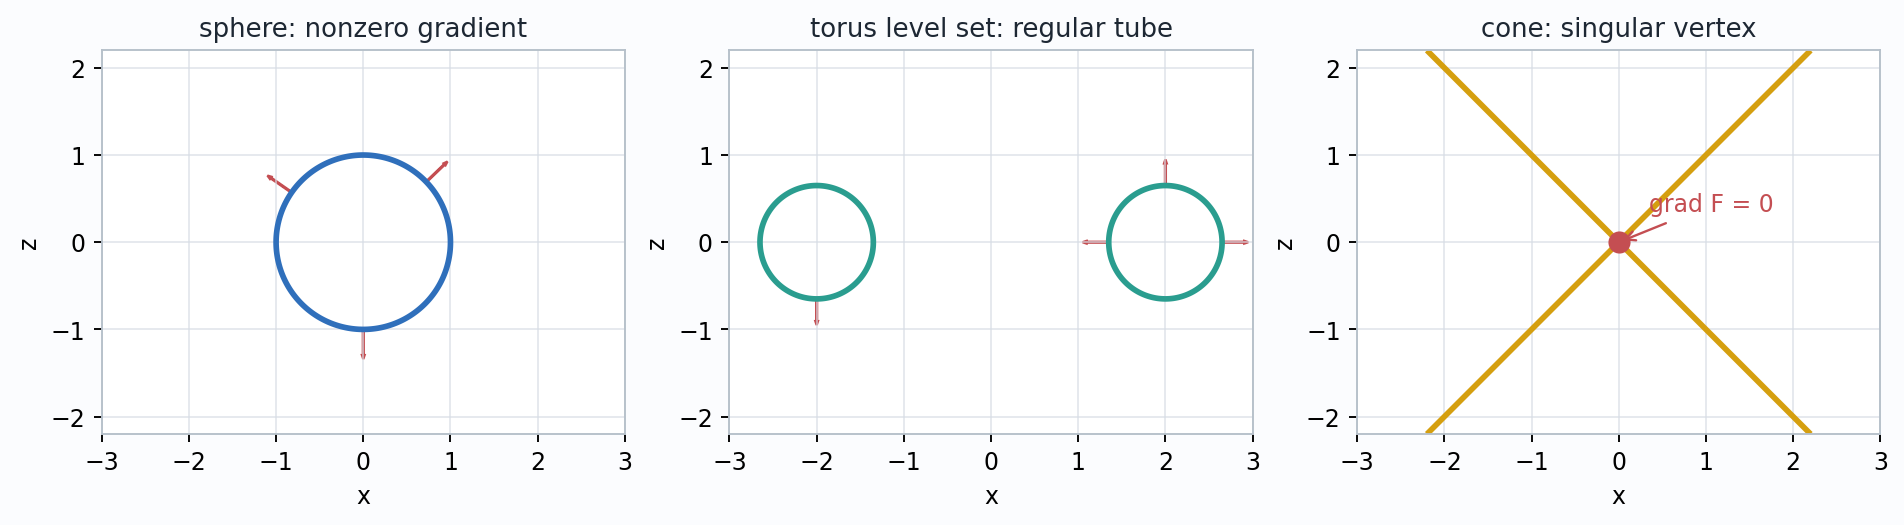

,value
sphere_gradient_identity_zero,0
cone_vertex_gradient_norm,0.0
torus_level_residual_max,0.0
torus_gradient_norm_min,14.04
torus_gradient_norm_max,27.56


In [2]:
x, y, z, R_sym, r_sym = sp.symbols("x y z R r", positive=True)
sphere_F = x**2 + y**2 + z**2 - 1
cone_F = x**2 + y**2 - z**2
torus_F = (x**2 + y**2 + z**2 + R_sym**2 - r_sym**2) ** 2 - 4 * R_sym**2 * (x**2 + y**2)

def grad_sym(F):
    return sp.Matrix([sp.diff(F, var) for var in (x, y, z)])

sphere_grad_identity = sp.simplify(grad_sym(sphere_F).dot(grad_sym(sphere_F)) - 4 * (x**2 + y**2 + z**2))
cone_vertex_grad_norm = sp.sqrt(grad_sym(cone_F).dot(grad_sym(cone_F))).subs({x: 0, y: 0, z: 0})
R0, r0 = 2.0, 0.65
u = np.linspace(0, 2 * np.pi, 120, endpoint=False)
v = np.linspace(0, 2 * np.pi, 96, endpoint=False)
U, V = np.meshgrid(u, v, indexing="ij")
X = (R0 + r0 * np.cos(U)) * np.cos(V)
Y = (R0 + r0 * np.cos(U)) * np.sin(V)
Z = r0 * np.sin(U)
A = X**2 + Y**2 + Z**2 + R0**2 - r0**2
Fx = 4 * X * (A - 2 * R0**2)
Fy = 4 * Y * (A - 2 * R0**2)
Fz = 4 * Z * A
torus_grad_norm = np.sqrt(Fx**2 + Fy**2 + Fz**2)
torus_level_residual = A**2 - 4 * R0**2 * (X**2 + Y**2)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))
xx = np.linspace(-3.0, 3.0, 420)
zz = np.linspace(-2.2, 2.2, 360)
XX, ZZ = np.meshgrid(xx, zz)
axes[0].contour(XX, ZZ, XX**2 + ZZ**2 - 1, levels=[0], colors=[PALETTE["blue"]], linewidths=2.4)
for px, pz in [(0.72, 0.69), (-0.82, 0.57), (0.0, -1.0)]:
    g = np.array([2 * px, 2 * pz]); g = 0.34 * g / np.linalg.norm(g)
    axes[0].arrow(px, pz, g[0], g[1], width=0.01, color=PALETTE["red"], length_includes_head=True)
style_axis(axes[0], "sphere: nonzero gradient", equal=True)
axes[0].set_xlabel("x"); axes[0].set_ylabel("z")

torus_slice = (XX**2 + ZZ**2 + R0**2 - r0**2) ** 2 - 4 * R0**2 * XX**2
axes[1].contour(XX, ZZ, torus_slice, levels=[0], colors=[PALETTE["teal"]], linewidths=2.4)
for px, pz in [(R0 + r0, 0.0), (R0, r0), (R0 - r0, 0.0), (-R0, -r0)]:
    A2 = px**2 + pz**2 + R0**2 - r0**2
    g = np.array([4 * px * (A2 - 2 * R0**2), 4 * pz * A2]); g = 0.30 * g / np.linalg.norm(g)
    axes[1].arrow(px, pz, g[0], g[1], width=0.01, color=PALETTE["red"], length_includes_head=True)
style_axis(axes[1], "torus level set: regular tube", equal=True)
axes[1].set_xlabel("x"); axes[1].set_ylabel("z")

axes[2].contour(XX, ZZ, XX**2 - ZZ**2, levels=[0], colors=[PALETTE["gold"]], linewidths=2.4)
axes[2].scatter([0], [0], s=70, color=PALETTE["red"], zorder=4)
axes[2].annotate("grad F = 0", xy=(0, 0), xytext=(0.35, 0.35), arrowprops={"arrowstyle": "->", "color": PALETTE["red"]}, color=PALETTE["red"])
style_axis(axes[2], "cone: singular vertex", equal=True)
axes[2].set_xlabel("x"); axes[2].set_ylabel("z")
level_png = save_figure("level_surface_gradient", fig, "level-surface-gradient-regularity.png")
level_checks = {"sphere_gradient_identity_zero": str(sphere_grad_identity), "cone_vertex_gradient_norm": float(cone_vertex_grad_norm), "torus_level_residual_max": float(np.max(np.abs(torus_level_residual))), "torus_gradient_norm_min": float(np.min(torus_grad_norm)), "torus_gradient_norm_max": float(np.max(torus_grad_norm))}
CHECKS["level_surface"] = level_checks
write_json("level_surface_checks", level_checks, "level-surface-regularity.json")
display_local_artifact(level_png, width=980)
display(pd.DataFrame([level_checks]).T.rename(columns={0: "value"}))

The level-set test is local. The sphere and torus can be covered by patches because their gradients do not vanish on the sampled zero set. The cone shows the failure mode: at the vertex no tangent plane can be selected from a normal vector.

## 5.2 Quadric Surfaces: Matrix Shape, Visible Shape

A quadric is controlled by a symmetric quadratic part. After translating the origin and applying an orthogonal change of coordinates, cross terms disappear. The remaining signs and zero coefficients produce ellipsoids, hyperboloids, paraboloids, cones, and cylinders.

The interactive atlas makes the classification inspectable: rotate the families and compare which axes are bounded, which directions open, and where the cone has to lose its vertex before it is a surface.

In [3]:
def surface_ellipsoid(a=1.45, b=1.0, c=0.72, nu=60, nv=36):
    theta = np.linspace(0, 2*np.pi, nu); phi = np.linspace(-np.pi/2, np.pi/2, nv)
    T, P = np.meshgrid(theta, phi)
    return a*np.cos(P)*np.cos(T), b*np.cos(P)*np.sin(T), c*np.sin(P)

def surface_one_sheet(a=0.8, b=1.05, c=0.62, nu=60, nv=38):
    theta = np.linspace(0, 2*np.pi, nu); s = np.linspace(-1.15, 1.15, nv)
    T, S = np.meshgrid(theta, s)
    return a*np.cosh(S)*np.cos(T), b*np.cosh(S)*np.sin(T), c*np.sinh(S)

def surface_two_sheet(a=0.72, b=0.92, c=0.68, sign=1, nu=60, nv=30):
    theta = np.linspace(0, 2*np.pi, nu); s = np.linspace(0, 1.1, nv)
    T, S = np.meshgrid(theta, s)
    return a*np.sinh(S)*np.cos(T), b*np.sinh(S)*np.sin(T), sign*c*np.cosh(S)

def surface_elliptic_paraboloid(n=54):
    xg = np.linspace(-1.3, 1.3, n); yg = np.linspace(-1.3, 1.3, n); Xg, Yg = np.meshgrid(xg, yg)
    return Xg, Yg, 0.45*(Xg**2 + (Yg/1.25)**2)

def surface_hyperbolic_paraboloid(n=58):
    xg = np.linspace(-1.35, 1.35, n); yg = np.linspace(-1.35, 1.35, n); Xg, Yg = np.meshgrid(xg, yg)
    return Xg, Yg, 0.55*(Xg**2 - Yg**2)

def surface_cone(c=0.75, nu=60, nv=44):
    theta = np.linspace(0, 2*np.pi, nu); zg = np.linspace(-1.25, 1.25, nv); T, Zg = np.meshgrid(theta, zg)
    return np.abs(Zg)/c*np.cos(T), np.abs(Zg)/c*np.sin(T), Zg

specs = [("Ellipsoid", surface_ellipsoid(), "Blues"), ("Hyperboloid, one sheet", surface_one_sheet(), "Viridis"), ("Hyperboloid, two sheets", None, "Purples"), ("Elliptic paraboloid", surface_elliptic_paraboloid(), "Greens"), ("Hyperbolic paraboloid", surface_hyperbolic_paraboloid(), "RdBu"), ("Cone without vertex", surface_cone(), "YlOrBr")]
fig = make_subplots(rows=2, cols=3, specs=[[{"type":"surface"}]*3, [{"type":"surface"}]*3], subplot_titles=[s[0] for s in specs], horizontal_spacing=0.02, vertical_spacing=0.06)
for index, (title, arrays, colorscale) in enumerate(specs, start=1):
    row = 1 if index <= 3 else 2; col = index if index <= 3 else index - 3
    if title == "Hyperboloid, two sheets":
        for sign in [1, -1]:
            Xq, Yq, Zq = surface_two_sheet(sign=sign)
            fig.add_trace(go.Surface(x=Xq, y=Yq, z=Zq, colorscale=colorscale, showscale=False, opacity=0.82), row=row, col=col)
    else:
        Xq, Yq, Zq = arrays
        fig.add_trace(go.Surface(x=Xq, y=Yq, z=Zq, colorscale=colorscale, showscale=False, opacity=0.86), row=row, col=col)
for scene_name in ["scene", "scene2", "scene3", "scene4", "scene5", "scene6"]:
    fig.update_layout({scene_name: {"aspectmode": "data", "xaxis": {"visible": False}, "yaxis": {"visible": False}, "zaxis": {"visible": False}}})
fig.update_layout(title="Chapter 5 quadric atlas: sign pattern controls surface type", height=820, margin={"l":0,"r":0,"t":80,"b":0})
quadric_html = save_plotly("quadric_atlas", fig, "quadric-atlas.html")
A_quadric = np.array([[2.0, 0.75, 0.0], [0.75, 1.2, 0.35], [0.0, 0.35, -0.9]])
eigenvalues, P = np.linalg.eigh(A_quadric)
diagonalized = P.T @ A_quadric @ P
offdiag = diagonalized - np.diag(np.diag(diagonalized))
Xh, Yh, Zh = surface_hyperbolic_paraboloid(n=34)
quadric_checks = {"sample_quadratic_matrix": A_quadric, "eigenvalues": eigenvalues, "signature_positive_negative_zero": [int(np.sum(eigenvalues > 1e-10)), int(np.sum(eigenvalues < -1e-10)), int(np.sum(np.abs(eigenvalues) <= 1e-10))], "diagonalization_offdiag_max": float(np.max(np.abs(offdiag))), "hyperbolic_paraboloid_residual_max": float(np.max(np.abs(Xh**2 - Yh**2 - Zh/0.55)))}
CHECKS["quadric"] = quadric_checks
write_json("quadric_checks", quadric_checks, "quadric-classification.json")
display_local_artifact(quadric_html, width="100%", height=720)
display(pd.DataFrame({"eigenvalue": eigenvalues}))

,eigenvalue
0,-0.962113
1,0.802308
2,2.459805


The numeric diagonalization mirrors the classification move: rotate the quadratic part until cross terms are negligible. The signs of the eigenvalues then tell us which directions are bounded, which open, and which require linear terms to produce parabolic forms.

## 5.3 Ruled Surfaces And Surfaces Of Revolution

A ruled surface has a straight-line parameter built into it. Fix `u`, vary `v`, and the point moves linearly. A surface of revolution has a circular parameter built into it. Fix the profile parameter and vary the angle, and the point travels on a circle around the axis.

The next visual keeps those mechanisms side by side. The helicoid and hyperbolic paraboloid show rulings. The catenoid shows a profile curve rotated about the `z`-axis.

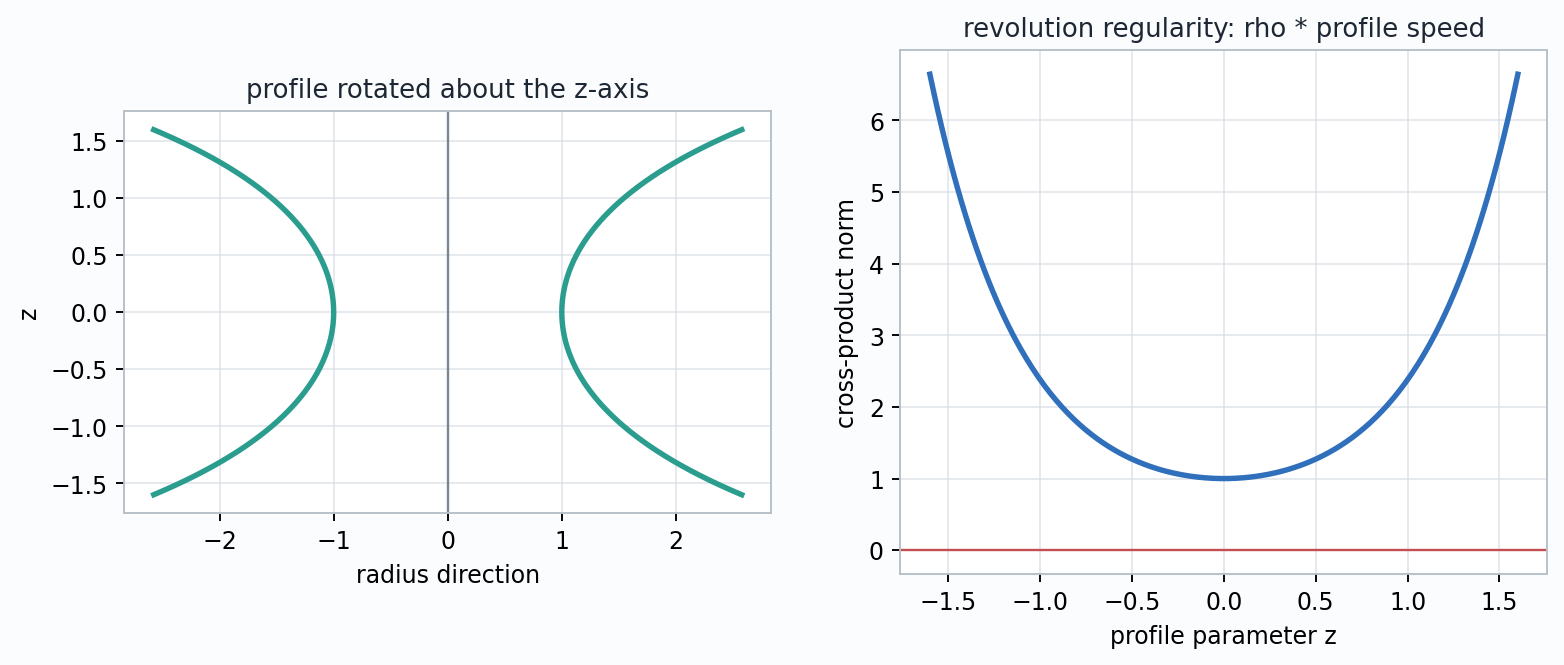

,value
revolution_cross_product_identity_zero,0
helicoid_ruling_second_difference_max,0.0
hyperbolic_paraboloid_ruling_v_second_difference_max,0.0
hyperbolic_paraboloid_ruling_u_second_difference_max,0.0
catenoid_profile_regularity_min,1.000029


In [4]:
theta = np.linspace(-2.1*np.pi, 2.1*np.pi, 96)
line_v = np.linspace(-1.25, 1.25, 42)
T, L = np.meshgrid(theta, line_v, indexing="ij")
pitch = 0.28
X_helicoid, Y_helicoid, Z_helicoid = L*np.cos(T), L*np.sin(T), pitch*T
u_hp = np.linspace(-1.25, 1.25, 72); v_hp = np.linspace(-1.25, 1.25, 72)
Uh, Vh = np.meshgrid(u_hp, v_hp, indexing="ij")
X_hp, Y_hp, Z_hp = 0.5*(Uh + Vh), 0.5*(Uh - Vh), Uh*Vh
z_profile = np.linspace(-1.35, 1.35, 64); angle = np.linspace(0, 2*np.pi, 84)
Zp, Ap = np.meshgrid(z_profile, angle, indexing="ij")
rho = np.cosh(Zp)
X_cat, Y_cat, Z_cat = rho*np.cos(Ap), rho*np.sin(Ap), Zp

fig = make_subplots(rows=1, cols=3, specs=[[{"type":"surface"}, {"type":"surface"}, {"type":"surface"}]], subplot_titles=["Helicoid: ruled", "Hyperbolic paraboloid: doubly ruled", "Catenoid: revolution"], horizontal_spacing=0.03)
fig.add_trace(go.Surface(x=X_helicoid, y=Y_helicoid, z=Z_helicoid, colorscale="Viridis", showscale=False, opacity=0.86), row=1, col=1)
for fixed in np.linspace(-2*np.pi, 2*np.pi, 8):
    fig.add_trace(go.Scatter3d(x=line_v*np.cos(fixed), y=line_v*np.sin(fixed), z=np.full_like(line_v, pitch*fixed), mode="lines", line={"color":"black", "width":5}, showlegend=False), row=1, col=1)
fig.add_trace(go.Surface(x=X_hp, y=Y_hp, z=Z_hp, colorscale="RdBu", showscale=False, opacity=0.82), row=1, col=2)
for fixed in np.linspace(-1.0, 1.0, 7):
    vv = np.linspace(-1.3, 1.3, 50); uu = np.linspace(-1.3, 1.3, 50)
    fig.add_trace(go.Scatter3d(x=0.5*(fixed+vv), y=0.5*(fixed-vv), z=fixed*vv, mode="lines", line={"color":"black", "width":4}, showlegend=False), row=1, col=2)
    fig.add_trace(go.Scatter3d(x=0.5*(uu+fixed), y=0.5*(uu-fixed), z=uu*fixed, mode="lines", line={"color":"white", "width":4}, showlegend=False), row=1, col=2)
fig.add_trace(go.Surface(x=X_cat, y=Y_cat, z=Z_cat, colorscale="Teal", showscale=False, opacity=0.86), row=1, col=3)
for scene_name in ["scene", "scene2", "scene3"]:
    fig.update_layout({scene_name: {"aspectmode":"data", "xaxis":{"visible":False}, "yaxis":{"visible":False}, "zaxis":{"visible":False}}})
fig.update_layout(title="Ruled parameter lines versus circular orbits of revolution", height=610, margin={"l":0,"r":0,"t":80,"b":0})
ruled_html = save_plotly("ruled_revolution", fig, "ruled-revolution-families.html")

u_var, v_var = sp.symbols("u v", real=True)
rho_fun = sp.Function("rho")(u_var); z_fun = sp.Function("zeta")(u_var)
sigma_rev = sp.Matrix([rho_fun*sp.cos(v_var), rho_fun*sp.sin(v_var), z_fun])
rev_cross = sigma_rev.diff(u_var).cross(sigma_rev.diff(v_var))
rev_norm_identity = sp.simplify(rev_cross.dot(rev_cross) - rho_fun**2*(sp.diff(rho_fun, u_var)**2 + sp.diff(z_fun, u_var)**2))
helicoid_second = np.diff(np.stack([X_helicoid, Y_helicoid, Z_helicoid], axis=-1), n=2, axis=1)
hp_second_v = np.diff(np.stack([X_hp, Y_hp, Z_hp], axis=-1), n=2, axis=1)
hp_second_u = np.diff(np.stack([X_hp, Y_hp, Z_hp], axis=-1), n=2, axis=0)
fig2, axes = plt.subplots(1, 2, figsize=(10.8, 4.0))
z_line = np.linspace(-1.6, 1.6, 300); rho_line = np.cosh(z_line)
axes[0].plot(rho_line, z_line, color=PALETTE["teal"], linewidth=2.3); axes[0].plot(-rho_line, z_line, color=PALETTE["teal"], linewidth=2.3); axes[0].axvline(0, color=PALETTE["gray"], linewidth=1.0)
style_axis(axes[0], "profile rotated about the z-axis", equal=True); axes[0].set_xlabel("radius direction"); axes[0].set_ylabel("z")
regularity = rho_line*np.sqrt(np.sinh(z_line)**2 + 1.0)
axes[1].plot(z_line, regularity, color=PALETTE["blue"], linewidth=2.3); axes[1].axhline(0, color=PALETTE["red"], linewidth=1.0)
style_axis(axes[1], "revolution regularity: rho * profile speed"); axes[1].set_xlabel("profile parameter z"); axes[1].set_ylabel("cross-product norm")
revolution_profile_png = save_figure("revolution_profile", fig2, "revolution-profile-regularity.png")
ruled_checks = {"revolution_cross_product_identity_zero": str(rev_norm_identity), "helicoid_ruling_second_difference_max": float(np.max(np.linalg.norm(helicoid_second, axis=-1))), "hyperbolic_paraboloid_ruling_v_second_difference_max": float(np.max(np.linalg.norm(hp_second_v, axis=-1))), "hyperbolic_paraboloid_ruling_u_second_difference_max": float(np.max(np.linalg.norm(hp_second_u, axis=-1))), "catenoid_profile_regularity_min": float(np.min(regularity))}
CHECKS["ruled_revolution"] = ruled_checks
write_json("ruled_revolution_checks", ruled_checks, "ruled-revolution.json")
display_local_artifact(ruled_html, width="100%", height=580)
display_local_artifact(revolution_profile_png, width=820)
display(pd.DataFrame([ruled_checks]).T.rename(columns={0: "value"}))

The symbolic identity explains the regularity condition for a revolution patch:

\[
\|\sigma_u \times \sigma_v\|^2 = \rho(u)^2\left(\rho'(u)^2 + \zeta'(u)^2\right).
\]

So nonzero profile speed is not enough if the profile meets the rotation axis. At such points this patch degenerates and the surface needs another chart.

## 5.4 Compact Surfaces: Closed, Bounded, And Topologically Diagnosed

Compactness in Euclidean space means closed and bounded. The bounded part is easy to see; the closed part is the one examples can hide. A punctured or open-ended bounded surface can sit inside a ball while still failing to contain its limiting points.

The mesh diagnostics below do not prove the classification theorem for compact surfaces, but they give concrete invariants for the basic sphere-like and torus-like models.

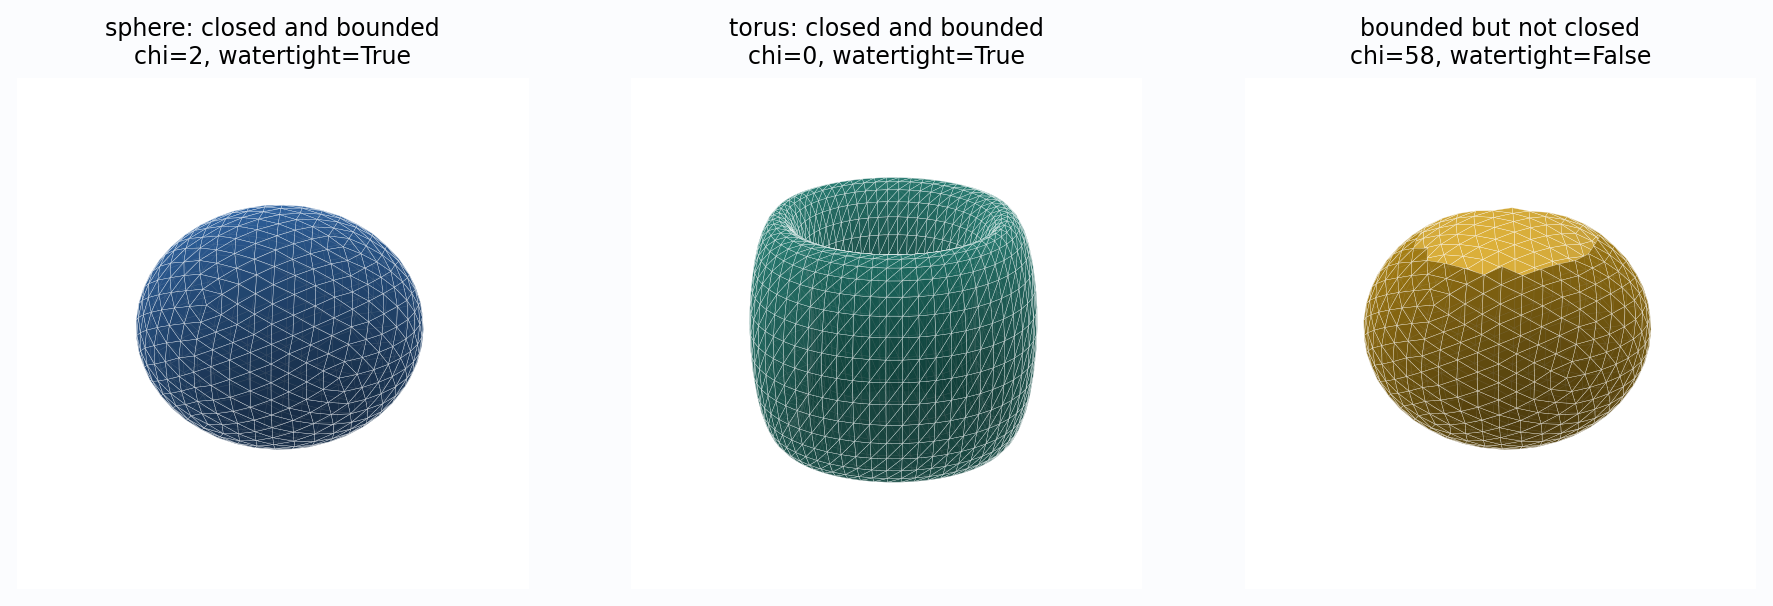

,name,vertices,edges,faces,euler_characteristic,watertight
0,sphere,642,1920,1280,2,True
1,torus,1792,5376,3584,0,True
2,bounded punctured sphere,642,1724,1140,58,False


In [5]:
def unique_edges(faces):
    edges = set()
    for tri in np.asarray(faces):
        for i, j in [(0, 1), (1, 2), (2, 0)]:
            a, b = int(tri[i]), int(tri[j]); edges.add(tuple(sorted((a, b))))
    return edges

def mesh_summary(name, vertices, faces):
    edges = unique_edges(faces)
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces, process=False)
    return {"name": name, "vertices": int(len(vertices)), "edges": int(len(edges)), "faces": int(len(faces)), "euler_characteristic": int(len(vertices) - len(edges) + len(faces)), "trimesh_euler_number": int(mesh.euler_number), "watertight": bool(mesh.is_watertight), "bounds_min": mesh.bounds[0], "bounds_max": mesh.bounds[1]}, mesh

def torus_mesh(nu=56, nv=32, R=2.0, r=0.55):
    vertices, faces = [], []
    for i in range(nu):
        uu = 2*np.pi*i/nu
        for j in range(nv):
            vv = 2*np.pi*j/nv
            vertices.append([(R + r*np.cos(vv))*np.cos(uu), (R + r*np.cos(vv))*np.sin(uu), r*np.sin(vv)])
    for i in range(nu):
        for j in range(nv):
            a = i*nv + j; b = ((i+1) % nu)*nv + j; c = ((i+1) % nu)*nv + ((j+1) % nv); d = i*nv + ((j+1) % nv)
            faces.extend([[a, b, c], [a, c, d]])
    return np.asarray(vertices, float), np.asarray(faces, int)

sphere_mesh = trimesh.creation.icosphere(subdivisions=3, radius=1.0)
sphere_summary, sphere_clean = mesh_summary("sphere", sphere_mesh.vertices, sphere_mesh.faces)
torus_vertices, torus_faces = torus_mesh()
torus_summary, torus_clean = mesh_summary("torus", torus_vertices, torus_faces)
mask = np.all(sphere_mesh.vertices[sphere_mesh.faces][:, :, 2] < 0.82, axis=1)
punctured_summary, punctured_clean = mesh_summary("bounded punctured sphere", sphere_mesh.vertices.copy(), sphere_mesh.faces[mask])
fig = plt.figure(figsize=(13.2, 4.2))
axes = [fig.add_subplot(1, 3, i + 1, projection="3d") for i in range(3)]
items = [(axes[0], sphere_clean, sphere_summary, "sphere: closed and bounded", PALETTE["blue"]), (axes[1], torus_clean, torus_summary, "torus: closed and bounded", PALETTE["teal"]), (axes[2], punctured_clean, punctured_summary, "bounded but not closed", PALETTE["gold"])]
for ax, mesh, summary, title, color in items:
    ax.plot_trisurf(mesh.vertices[:,0], mesh.vertices[:,1], mesh.vertices[:,2], triangles=mesh.faces, color=color, alpha=0.82, linewidth=0.15, edgecolor="white")
    ax.set_title(f"{title}\nchi={summary['euler_characteristic']}, watertight={summary['watertight']}", fontsize=10)
    ax.set_box_aspect((1, 1, 0.75)); ax.set_axis_off(); ax.view_init(elev=22, azim=35)
compact_png = save_figure("compact_topology", fig, "compact-topology-mesh-diagnostics.png")
compact_checks = {"sphere": sphere_summary, "torus": torus_summary, "bounded_punctured_sphere": punctured_summary}
CHECKS["compact_topology"] = compact_checks
write_json("compact_topology_checks", compact_checks, "compact-topology.json")
display_local_artifact(compact_png, width=980)
display(pd.DataFrame([sphere_summary, torus_summary, punctured_summary])[["name", "vertices", "edges", "faces", "euler_characteristic", "watertight"]])

The sphere has Euler characteristic `2`; the torus has Euler characteristic `0`. The punctured model is bounded, but it is not watertight and misses limiting boundary points. This is the computational version of why compactness is not the same as fitting inside a finite box.

## 5.5 Triply Orthogonal Systems: Confocal Quadrics

A triply orthogonal system is a three-parameter family of surfaces whose coordinate surfaces meet pairwise at right angles. The confocal quadric example is computationally useful because the normal vectors come from gradients of scalar functions.

For constants `a1 < a2 < a3`, define

\[
F_t(x,y,z) = \frac{x^2}{a_1-t} + \frac{y^2}{a_2-t} + \frac{z^2}{a_3-t}.
\]

At a point with nonzero coordinates, one parameter lies in each interval `(-infinity, a1)`, `(a1, a2)`, and `(a2, a3)` with `F_t = 1`. The three corresponding surfaces are mutually orthogonal.

In [6]:
axis_sq = np.array([1.0, 2.25, 4.0])
point = np.array([0.72, 0.95, 1.18])

def F_confocal(t, xyz=point, a=axis_sq):
    return float(np.sum(xyz**2 / (a - t)))

eps = 1e-7
roots = np.array([
    brentq(lambda t: F_confocal(t) - 1.0, -50.0, axis_sq[0] - eps),
    brentq(lambda t: F_confocal(t) - 1.0, axis_sq[0] + eps, axis_sq[1] - eps),
    brentq(lambda t: F_confocal(t) - 1.0, axis_sq[1] + eps, axis_sq[2] - eps),
])
normal_vectors = np.array([point / (axis_sq - root) for root in roots])
normal_unit = normal_vectors / np.linalg.norm(normal_vectors, axis=1, keepdims=True)
normal_dot = normal_unit @ normal_unit.T
fig = go.Figure()
theta = np.linspace(0, 2*np.pi, 76)
# Ellipsoid.
t = roots[0]; den = axis_sq - t; phi = np.linspace(-np.pi/2, np.pi/2, 42); T, P = np.meshgrid(theta, phi)
fig.add_trace(go.Surface(x=np.sqrt(den[0])*np.cos(P)*np.cos(T), y=np.sqrt(den[1])*np.cos(P)*np.sin(T), z=np.sqrt(den[2])*np.sin(P), opacity=0.35, colorscale="Blues", showscale=False, name="ellipsoid"))
# One-sheet hyperboloid.
t = roots[1]; den = axis_sq - t; s = np.linspace(-0.95, 0.95, 46); T, S = np.meshgrid(theta, s)
fig.add_trace(go.Surface(x=np.sqrt(-den[0])*np.sinh(S), y=np.sqrt(den[1])*np.cosh(S)*np.cos(T), z=np.sqrt(den[2])*np.cosh(S)*np.sin(T), opacity=0.35, colorscale="Greens", showscale=False, name="one-sheet"))
# Two-sheet hyperboloid.
t = roots[2]; den = axis_sq - t; s = np.linspace(0.0, 0.86, 36); T, S = np.meshgrid(theta, s)
for sign in [1, -1]:
    fig.add_trace(go.Surface(x=np.sqrt(-den[0])*np.sinh(S)*np.cos(T), y=np.sqrt(-den[1])*np.sinh(S)*np.sin(T), z=sign*np.sqrt(den[2])*np.cosh(S), opacity=0.32, colorscale="Purples", showscale=False, name="two-sheet"))
fig.add_trace(go.Scatter3d(x=[point[0]], y=[point[1]], z=[point[2]], mode="markers", marker={"size":6, "color":"black"}, name="sample point"))
for normal, color in zip(normal_unit, [PALETTE["blue"], PALETTE["green"], PALETTE["violet"]]):
    end = point + 0.55*normal
    fig.add_trace(go.Scatter3d(x=[point[0], end[0]], y=[point[1], end[1]], z=[point[2], end[2]], mode="lines", line={"color":color, "width":8}, showlegend=False))
fig.update_layout(title="Confocal quadrics through one point: normals are pairwise perpendicular", scene={"aspectmode":"data"}, height=680, margin={"l":0,"r":0,"t":60,"b":0})
triply_html = save_plotly("triply_orthogonal", fig, "triply-orthogonal-confocal-quadrics.html")
triply_checks = {"axis_squares": axis_sq, "sample_point": point, "parameters_u_v_w": roots, "F_t_values_at_sample_point": [F_confocal(root) for root in roots], "normal_dot_matrix": normal_dot, "max_off_diagonal_normal_dot_abs": float(np.max(np.abs(normal_dot - np.eye(3))))}
CHECKS["triply_orthogonal"] = triply_checks
write_json("triply_orthogonal_checks", triply_checks, "triply-orthogonal-system.json")
display_local_artifact(triply_html, width="100%", height=650)
display(pd.DataFrame(normal_dot, columns=["ellipsoid", "one-sheet", "two-sheet"], index=["ellipsoid", "one-sheet", "two-sheet"]))

,ellipsoid,one-sheet,two-sheet
ellipsoid,1.000000e+00,-3.559249e-14,-1.439527e-13
one-sheet,-3.559249e-14,1.000000e+00,-9.175993e-14
two-sheet,-1.439527e-13,-9.175993e-14,1.000000e+00


The dot products vanish for a simple reason. If the same point lies on `F_s = 1` and `F_t = 1`, subtract the two equations. The result is proportional to the dot product of the two gradient normals, so the tangent planes meet orthogonally.

## 5.6 Inverse-Function-Theorem Local Model Control

The inverse function theorem gives a local inverse when the relevant Jacobian is nonzero. For surfaces, this becomes a chart-selection rule: choose a coordinate projection whose two-by-two determinant is nonzero. Equivalently, choose a component of the normal vector that is not zero.

On the torus below, the best projection changes from patch to patch. The heatmap names which graph model is strongest at each sampled point.

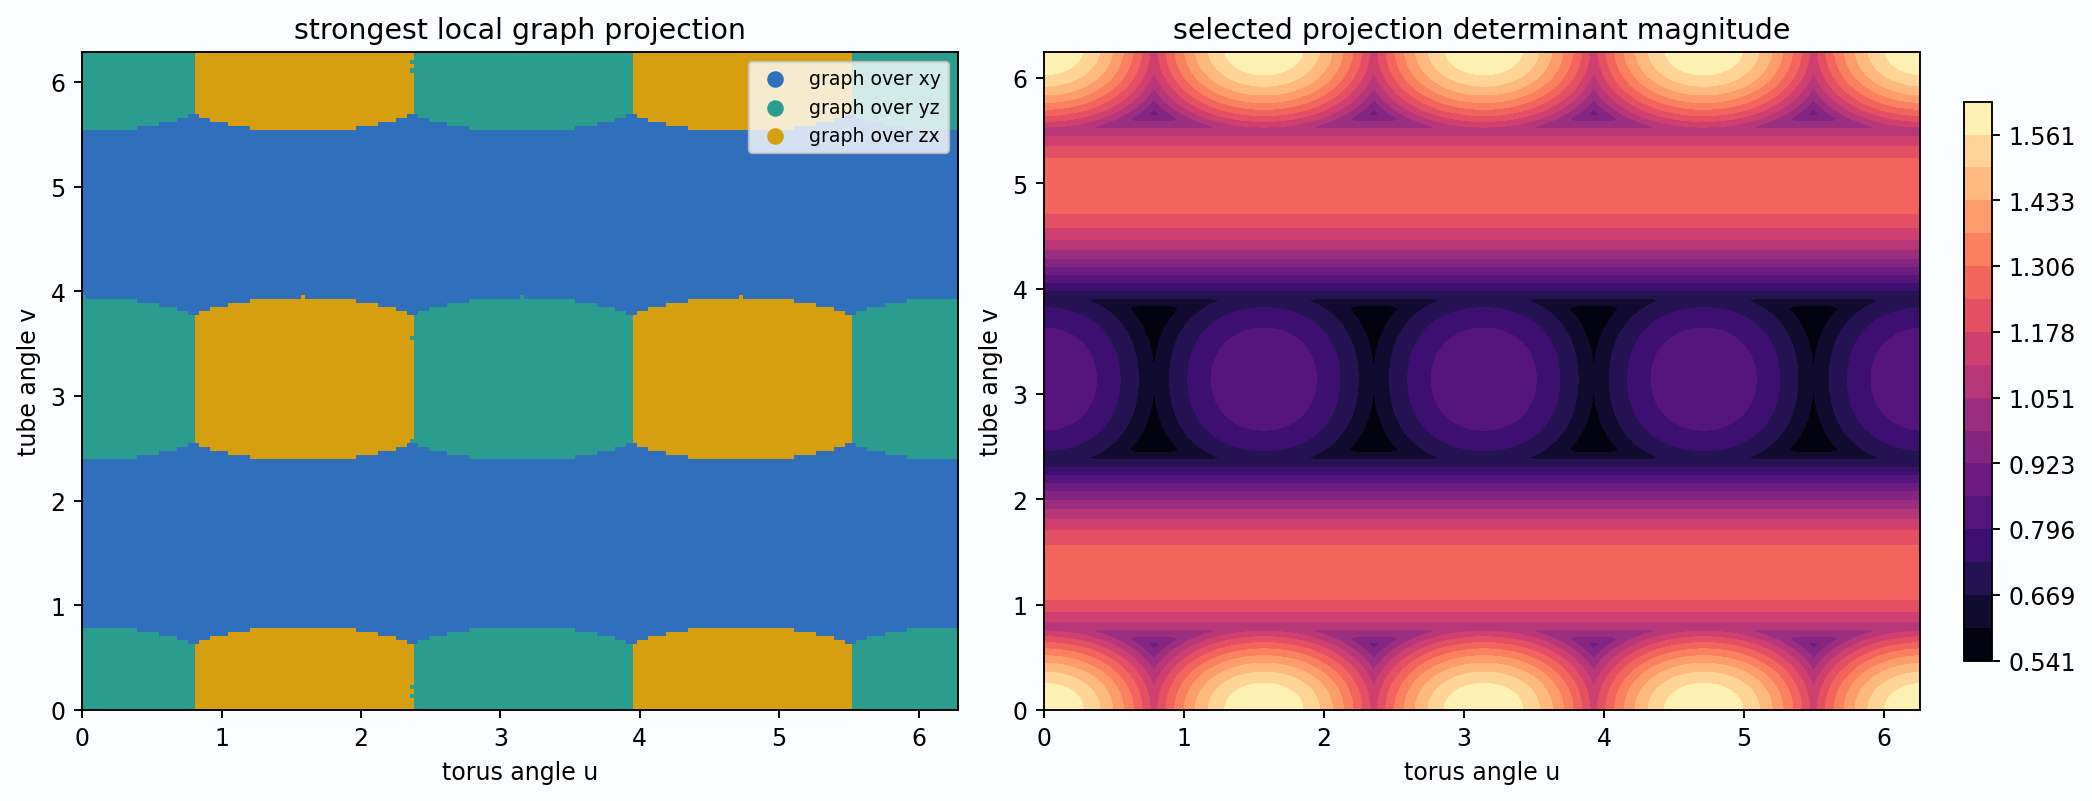

,value
min_best_projection_abs_det,0.541128
max_best_projection_abs_det,1.6244
xy_projection_near_zero_fraction,0.05
graph_identity_for_upper_sphere,0
graph_derivative_formula_x_zero,0
graph_derivative_formula_y_zero,0


In [7]:
R_torus, r_torus = 2.0, 0.62
u = np.linspace(0, 2*np.pi, 240, endpoint=False); v = np.linspace(0, 2*np.pi, 160, endpoint=False)
U, V = np.meshgrid(u, v, indexing="ij")
Su = np.stack([-(R_torus + r_torus*np.cos(V))*np.sin(U), (R_torus + r_torus*np.cos(V))*np.cos(U), np.zeros_like(U)], axis=-1)
Sv = np.stack([-r_torus*np.sin(V)*np.cos(U), -r_torus*np.sin(V)*np.sin(U), r_torus*np.cos(V)], axis=-1)
N = np.cross(Su, Sv)
projection_dets = np.stack([N[..., 2], N[..., 0], N[..., 1]], axis=-1)  # xy, yz, zx
abs_dets = np.abs(projection_dets)
chart_index = np.argmax(abs_dets, axis=-1)
best_det = np.max(abs_dets, axis=-1)
xy_bad_fraction = float(np.mean(abs_dets[..., 0] < 0.08))
x_sym, y_sym = sp.symbols("x y", real=True)
g_upper = sp.sqrt(1 - x_sym**2 - y_sym**2)
F_sphere_graph = x_sym**2 + y_sym**2 + z**2 - 1
graph_identity = sp.simplify(F_sphere_graph.subs(z, g_upper))
graph_gx_formula = sp.simplify(sp.diff(g_upper, x_sym) + (2*x_sym)/(2*g_upper))
graph_gy_formula = sp.simplify(sp.diff(g_upper, y_sym) + (2*y_sym)/(2*g_upper))
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.6), constrained_layout=True)
chart_cmap = plt.matplotlib.colors.ListedColormap([PALETTE["blue"], PALETTE["teal"], PALETTE["gold"]])
axes[0].imshow(chart_index.T, origin="lower", aspect="auto", cmap=chart_cmap, extent=[0, 2*np.pi, 0, 2*np.pi], interpolation="nearest")
axes[0].set_title("strongest local graph projection"); axes[0].set_xlabel("torus angle u"); axes[0].set_ylabel("tube angle v")
for k, label in enumerate(["graph over xy", "graph over yz", "graph over zx"]):
    axes[0].scatter([], [], color=chart_cmap(k), label=label)
axes[0].legend(loc="upper right", fontsize=8, frameon=True)
cont = axes[1].contourf(U, V, best_det, levels=np.linspace(float(best_det.min()), float(best_det.max()), 18), cmap="magma")
axes[1].set_title("selected projection determinant magnitude"); axes[1].set_xlabel("torus angle u"); axes[1].set_ylabel("tube angle v")
fig.colorbar(cont, ax=axes[1], shrink=0.85)
ift_png = save_figure("inverse_function_chart_control", fig, "inverse-function-chart-control.png")
ift_checks = {"min_best_projection_abs_det": float(np.min(best_det)), "max_best_projection_abs_det": float(np.max(best_det)), "xy_projection_near_zero_fraction": xy_bad_fraction, "graph_identity_for_upper_sphere": str(graph_identity), "graph_derivative_formula_x_zero": str(graph_gx_formula), "graph_derivative_formula_y_zero": str(graph_gy_formula)}
CHECKS["inverse_function"] = ift_checks
write_json("inverse_function_checks", ift_checks, "inverse-function-chart-control.json")
display_local_artifact(ift_png, width=930)
display(pd.DataFrame([ift_checks]).T.rename(columns={0: "value"}))

The color changes are not a defect in the torus. They show why a surface is covered by an atlas instead of by one global graph. Where the `xy` projection is weak, another projection remains strong because the normal vector itself is never zero on the torus.

## Applied Lab: Diagnose A Surface Recipe

In this lab, each row is a surface recipe and each diagnostic asks one Chapter 5 question: Is it a level surface with nonzero gradient? Is it ruled by straight lines? Is it a surface of revolution with nonzero patch cross product? The point is not to memorize examples, but to turn every recipe into a testable geometric claim.

,recipe,chapter_family,primary_test,value,passes_regular_test
0,level sphere F=x^2+y^2+z^2-1,level surface,min |grad F| on samples,2.000000e+00,True
1,"saddle sigma(u,v)=((u+v)/2,(u-v)/2,uv)",ruled surface,max second difference along v-rulings,3.682193e-16,True
2,"wavy revolution rho(u)=1.25+0.22 cos(3u), z=u",surface of revolution,min rho * profile_speed,1.030026e+00,True


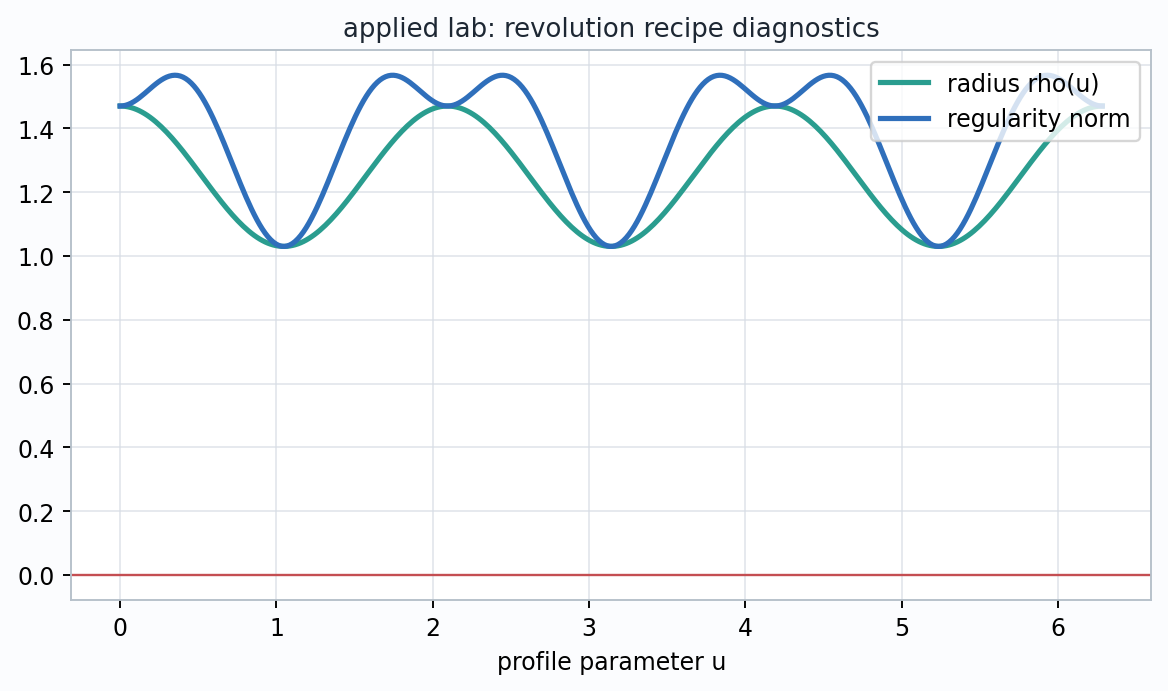

In [8]:
lab_rows = []
sphere_samples = np.array([[np.cos(t), np.sin(t), 0.0] for t in np.linspace(0, 2*np.pi, 24, endpoint=False)])
sphere_grad_norms = np.linalg.norm(2*sphere_samples, axis=1)
lab_rows.append({"recipe": "level sphere F=x^2+y^2+z^2-1", "chapter_family": "level surface", "primary_test": "min |grad F| on samples", "value": float(np.min(sphere_grad_norms)), "passes_regular_test": bool(np.min(sphere_grad_norms) > 1e-8)})

uu = np.linspace(-1.0, 1.0, 41); vv = np.linspace(-1.0, 1.0, 41)
UL, VL = np.meshgrid(uu, vv, indexing="ij")
lab_saddle = np.stack([0.5*(UL + VL), 0.5*(UL - VL), UL*VL], axis=-1)
saddle_second = np.diff(lab_saddle, n=2, axis=1)
lab_rows.append({"recipe": "saddle sigma(u,v)=((u+v)/2,(u-v)/2,uv)", "chapter_family": "ruled surface", "primary_test": "max second difference along v-rulings", "value": float(np.max(np.linalg.norm(saddle_second, axis=-1))), "passes_regular_test": bool(np.max(np.linalg.norm(saddle_second, axis=-1)) < 1e-12)})

u_lab = np.linspace(0, 2*np.pi, 360)
rho_lab = 1.25 + 0.22*np.cos(3*u_lab)
rho_prime_lab = -0.66*np.sin(3*u_lab)
rev_norm_lab = rho_lab*np.sqrt(rho_prime_lab**2 + 1.0)
lab_rows.append({"recipe": "wavy revolution rho(u)=1.25+0.22 cos(3u), z=u", "chapter_family": "surface of revolution", "primary_test": "min rho * profile_speed", "value": float(np.min(rev_norm_lab)), "passes_regular_test": bool(np.min(rev_norm_lab) > 1e-8)})

lab_df = pd.DataFrame(lab_rows)
write_csv("applied_lab_table", lab_df, "applied-lab-recipe-diagnostics.csv")
lab_checks = {"all_lab_recipes_pass": bool(lab_df["passes_regular_test"].all()), "min_reported_value": float(lab_df["value"].min()), "table_rows": int(len(lab_df))}
CHECKS["applied_lab"] = lab_checks
write_json("applied_lab_checks", lab_checks, "applied-lab.json")
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.plot(u_lab, rho_lab, color=PALETTE["teal"], linewidth=2.2, label="radius rho(u)")
ax.plot(u_lab, rev_norm_lab, color=PALETTE["blue"], linewidth=2.2, label="regularity norm")
ax.axhline(0, color=PALETTE["red"], linewidth=1.0)
style_axis(ax, "applied lab: revolution recipe diagnostics")
ax.set_xlabel("profile parameter u"); ax.legend(loc="upper right")
lab_png = save_figure("applied_lab_figure", fig, "applied-lab-surface-recipe-diagnostics.png")
display(lab_df)
display_local_artifact(lab_png, width=760)

## Final Sanity Checks

The final cell checks artifact existence, nonzero artifact size, PNG nonblank statistics, HTML Plotly payloads, and the chapter-specific identities used above. If this cell passes, the notebook has generated a reproducible set of visual and numeric evidence for Chapter 5.

In [9]:
artifact_report = {}
for key, path in ARTIFACTS.items():
    suffix = path.suffix.lower()
    min_bytes = 2048 if suffix == ".png" else 10000 if suffix == ".html" else 64
    checked = assert_artifact(path, min_bytes=min_bytes)
    entry = {"path": checked.relative_to(BOOK_ROOT).as_posix(), "bytes": checked.stat().st_size}
    if suffix == ".png":
        entry.update(require_nonblank_png(checked, min_width=240, min_height=180, min_std=1.0))
    elif suffix == ".html":
        html_text = checked.read_text(encoding="utf-8")
        entry["contains_plotly_newplot"] = "Plotly.newPlot" in html_text
        assert entry["contains_plotly_newplot"]
    elif suffix == ".json":
        entry["json_keys"] = sorted(json.loads(checked.read_text(encoding="utf-8")).keys())[:8]
    elif suffix == ".csv":
        entry["rows"] = int(len(pd.read_csv(checked)))
    artifact_report[key] = entry

assert CHECKS["level_surface"]["sphere_gradient_identity_zero"] == "0"
assert CHECKS["level_surface"]["cone_vertex_gradient_norm"] == 0.0
assert CHECKS["level_surface"]["torus_gradient_norm_min"] > 1.0
assert CHECKS["level_surface"]["torus_level_residual_max"] < 1e-9
assert CHECKS["quadric"]["diagonalization_offdiag_max"] < 1e-12
assert CHECKS["quadric"]["hyperbolic_paraboloid_residual_max"] < 1e-12
assert CHECKS["ruled_revolution"]["revolution_cross_product_identity_zero"] == "0"
assert CHECKS["ruled_revolution"]["helicoid_ruling_second_difference_max"] < 1e-12
assert CHECKS["ruled_revolution"]["hyperbolic_paraboloid_ruling_v_second_difference_max"] < 1e-12
assert CHECKS["ruled_revolution"]["hyperbolic_paraboloid_ruling_u_second_difference_max"] < 1e-12
assert CHECKS["compact_topology"]["sphere"]["euler_characteristic"] == 2
assert CHECKS["compact_topology"]["sphere"]["watertight"] is True
assert CHECKS["compact_topology"]["torus"]["euler_characteristic"] == 0
assert CHECKS["compact_topology"]["torus"]["watertight"] is True
assert CHECKS["compact_topology"]["bounded_punctured_sphere"]["watertight"] is False
assert CHECKS["triply_orthogonal"]["max_off_diagonal_normal_dot_abs"] < 1e-10
assert CHECKS["inverse_function"]["min_best_projection_abs_det"] > 0.45
assert CHECKS["inverse_function"]["graph_identity_for_upper_sphere"] == "0"
assert CHECKS["inverse_function"]["graph_derivative_formula_x_zero"] == "0"
assert CHECKS["inverse_function"]["graph_derivative_formula_y_zero"] == "0"
assert CHECKS["applied_lab"]["all_lab_recipes_pass"] is True

final_sanity = {"source_span": SOURCE_SPAN, "artifact_count": len(artifact_report), "artifact_report": artifact_report, "core_checks": CHECKS, "status": "passed"}
final_sanity_path = write_json("final_sanity", final_sanity, "final-sanity.json")
assert_artifact(final_sanity_path, min_bytes=512)
display(pd.DataFrame([{"check_family": key, "status": "passed"} for key in sorted(CHECKS)]))
print(f"final_sanity saved to {final_sanity_path.relative_to(BOOK_ROOT).as_posix()}")

,check_family,status
0,applied_lab,passed
1,compact_topology,passed
2,inverse_function,passed
3,level_surface,passed
4,quadric,passed
5,ruled_revolution,passed
6,triply_orthogonal,passed


final_sanity saved to artifacts/chapter-05/checks/final-sanity.json


## Takeaways

- A surface recipe is only a surface where its regularity test passes: nonzero gradient for a level set, nonzero cross product for a patch, or nonzero chart Jacobian for a local graph.
- Quadrics are organized by linear algebra. Orthogonal diagonalization and completing squares explain why the visible families are limited.
- Ruled and revolution surfaces encode different geometric motions: straight lines versus circular orbits.
- Compact embedded examples need both metric and topological diagnostics; bounded visual appearance alone is not enough.
- Triply orthogonal systems turn gradients into coordinate geometry: perpendicular normals give perpendicular tangent planes.
- The inverse function theorem is a practical chart-control tool: choose the projection whose determinant is not close to zero.